# Actividad 3 - Taller EDA

## Análisis exploratorio de datos: Students Performance in Exams

**Autor:** Stiven

### Descripción

En este proyecto se realiza un análisis exploratorio de datos (EDA)
sobre el rendimiento académico de estudiantes.

El conjunto de datos contiene información relacionada con:
- Género
- Grupo étnico
- Nivel educativo de los padres
- Tipo de almuerzo
- Curso de preparación para el examen
- Puntajes de matemáticas
- Puntajes de lectura
- Puntajes de escritura

El análisis se realiza utilizando Python, Pandas y Matplotlib.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
from google.colab import files
upload = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [13]:
df = pd.read_csv("StudentsPerformance.csv")

In [14]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
df.shape

(1000, 8)

## 1. Exploración inicial

El conjunto de datos contiene 1.000 registros correspondientes a
estudiantes y 8 variables relacionadas con sus características y
rendimiento académico.

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [18]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [20]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


### Valores nulos

Se realizó una revisión de los valores nulos en todas las variables.
No se encontraron datos faltantes, por lo que no es necesario aplicar
métodos de imputación.

In [21]:
df.duplicated().sum()

np.int64(0)

### Datos duplicados

Se verificó la existencia de registros duplicados y no se encontraron
duplicados en el conjunto de datos.

In [22]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [23]:
for columna in df.select_dtypes(include=['object']).columns:
    print(f"\n {columna}")
    print(df[columna].value_counts())


 gender
gender
female    518
male      482
Name: count, dtype: int64

 race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

 parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

 lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

 test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [24]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [25]:
df.columns = [
    "genero",
    "grupo_etnico",
    "educacion_padres",
    "almuerzo",
    "preparacion_examen",
    "nota_matematicas",
    "nota_lectura",
    "nota_escritura"
]

In [26]:
df.columns

Index(['genero', 'grupo_etnico', 'educacion_padres', 'almuerzo',
       'preparacion_examen', 'nota_matematicas', 'nota_lectura',
       'nota_escritura'],
      dtype='object')

### Limpieza de nombres de columnas

Se modificaron los nombres de las columnas para facilitar su
lectura y utilización durante el análisis. Se eliminaron espacios
y caracteres especiales, utilizando nombres descriptivos en
español.

In [27]:
df.dtypes

,0
genero,object
grupo_etnico,object
educacion_padres,object
almuerzo,object
preparacion_examen,object
nota_matematicas,int64
nota_lectura,int64
nota_escritura,int64


In [28]:
df.isnull().sum()

,0
genero,0
grupo_etnico,0
educacion_padres,0
almuerzo,0
preparacion_examen,0
nota_matematicas,0
nota_lectura,0
nota_escritura,0


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df["promedio"] = (
    df["nota_matematicas"] +
    df["nota_lectura"] +
    df["nota_escritura"]
) / 3

In [32]:
df.head()

,genero,grupo_etnico,educacion_padres,almuerzo,preparacion_examen,nota_matematicas,nota_lectura,nota_escritura,promedio
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [34]:
df["promedio"] = df["promedio"].round(2)

In [35]:
df.head()

,genero,grupo_etnico,educacion_padres,almuerzo,preparacion_examen,nota_matematicas,nota_lectura,nota_escritura,promedio
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


### Creación de la variable promedio

Se creó una nueva variable llamada `promedio`, calculada a partir
del promedio de las notas de matemáticas, lectura y escritura.
Esta variable permitirá analizar de manera general el rendimiento
académico de cada estudiante.

In [36]:
df["promedio"].describe()

,promedio
count,1000.000000
mean,67.770580
std,14.257311
min,9.000000
25%,58.330000
50%,68.330000
75%,77.670000
max,100.000000


In [37]:
estudiantes_alto_rendimiento = df[df["promedio"] >= 90]

estudiantes_alto_rendimiento.head()

,genero,grupo_etnico,educacion_padres,almuerzo,preparacion_examen,nota_matematicas,nota_lectura,nota_escritura,promedio
2,female,group B,master's degree,standard,none,90,95,93,92.67
6,female,group B,some college,standard,completed,88,95,92,91.67
104,male,group C,some college,standard,completed,98,86,90,91.33
106,female,group D,master's degree,standard,none,87,100,100,95.67
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.67


In [38]:
len(estudiantes_alto_rendimiento)

52

In [39]:
estudiantes_alto_rendimiento.shape

(52, 9)

### Filtrado de estudiantes

Se realizó un filtro para identificar los estudiantes cuyo promedio
académico es igual o superior a 90 puntos.

In [40]:
df[[
    "genero",
    "nota_matematicas",
    "nota_lectura",
    "nota_escritura",
    "promedio"
]].head()

,genero,nota_matematicas,nota_lectura,nota_escritura,promedio
0,female,72,72,74,72.67
1,female,69,90,88,82.33
2,female,90,95,93,92.67
3,male,47,57,44,49.33
4,male,76,78,75,76.33


In [41]:
def clasificar_rendimiento(promedio):
    if promedio >= 90:
        return "Excelente"
    elif promedio >= 70:
        return "Bueno"
    elif promedio >= 60:
        return "Regular"
    else:
        return "Bajo"

df["nivel_rendimiento"] = df["promedio"].apply(clasificar_rendimiento)

In [42]:
df[["promedio", "nivel_rendimiento"]].head(10)

,promedio,nivel_rendimiento
0,72.67,Bueno
1,82.33,Bueno
2,92.67,Excelente
3,49.33,Bajo
4,76.33,Bueno
5,77.33,Bueno
6,91.67,Excelente
7,40.67,Bajo
8,65.00,Regular
9,49.33,Bajo


In [43]:
df['nivel_rendimiento'].value_counts()

,count
nivel_rendimiento,
Bueno,407
Bajo,285
Regular,256
Excelente,52


In [45]:
df.groupby("genero")["promedio"].mean().round(2)


,promedio
genero,
female,69.57
male,65.84


In [46]:
df.groupby("preparacion_examen")["promedio"].mean().round(2)

,promedio
preparacion_examen,
completed,72.67
none,65.04


In [47]:
df.groupby("educacion_padres")["promedio"].mean().round(2)

,promedio
educacion_padres,
associate's degree,69.57
bachelor's degree,71.92
high school,63.10
master's degree,73.60
some college,68.48
some high school,65.11


In [48]:
df.groupby("grupo_etnico")["promedio"].mean().round(2)

,promedio
grupo_etnico,
group A,62.99
group B,65.47
group C,67.13
group D,69.18
group E,72.75


Pregunta 1

¿Los estudiantes que realizaron el curso de preparación para el examen obtuvieron un promedio académico diferente de quienes no lo realizaron?

Pregunta 2

¿Cómo varía el promedio académico según el nivel educativo de los padres?

Pregunta 3

¿Cómo se distribuyen los estudiantes según su nivel de rendimiento académico?

Pregunta 4

¿Existe una relación entre la nota de matemáticas y la nota de lectura?

Pregunta 5

¿Cómo se comportan las notas de matemáticas, lectura y escritura según el género?

In [49]:
import matplotlib.pyplot as plt


Gráfica 1 — Curso de preparación vs. promedio
Pregunta 1

¿Los estudiantes que realizaron el curso de preparación para el examen obtuvieron un promedio académico diferente de quienes no lo realizaron?

In [50]:
promedio_preparacion = (
    df.groupby("preparacion_examen")["promedio"]
    .mean()
    .sort_values(ascending=False)
)

promedio_preparacion

,promedio
preparacion_examen,
completed,72.669469
none,65.038801


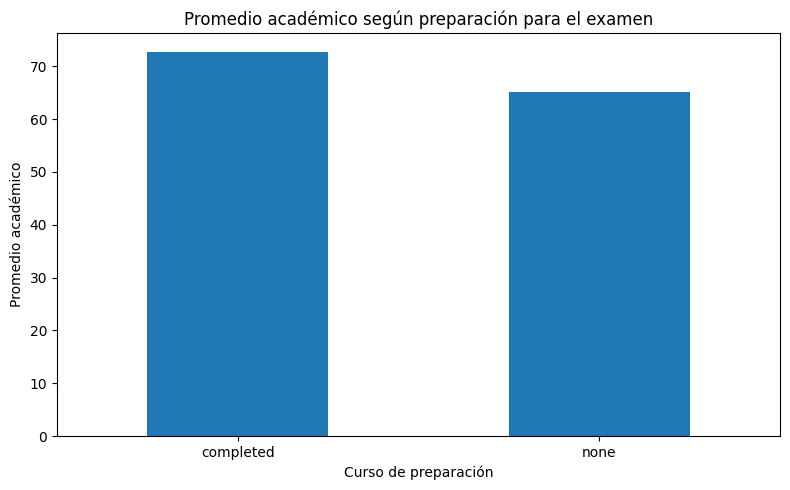

In [51]:
plt.figure(figsize=(8, 5))

promedio_preparacion.plot(kind="bar")

plt.title("Promedio académico según preparación para el examen")
plt.xlabel("Curso de preparación")
plt.ylabel("Promedio académico")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

 Interpretación

La gráfica permite comparar el promedio académico de los estudiantes
según si realizaron o no el curso de preparación para el examen.

A partir de los resultados obtenidos, se puede observar una diferencia
entre los promedios de ambos grupos. Esta diferencia permite analizar
la relación entre la preparación para el examen y el rendimiento
académico.

Gráfica 2 — Educación de los padres
Pregunta 2

¿Cómo varía el promedio académico según el nivel educativo de los padres?

In [52]:
promedio_educacion = (
    df.groupby("educacion_padres")["promedio"]
    .mean()
    .sort_values(ascending=False)
)

promedio_educacion

,promedio
educacion_padres,
master's degree,73.598644
bachelor's degree,71.923983
associate's degree,69.568964
some college,68.476106
some high school,65.107654
high school,63.097194


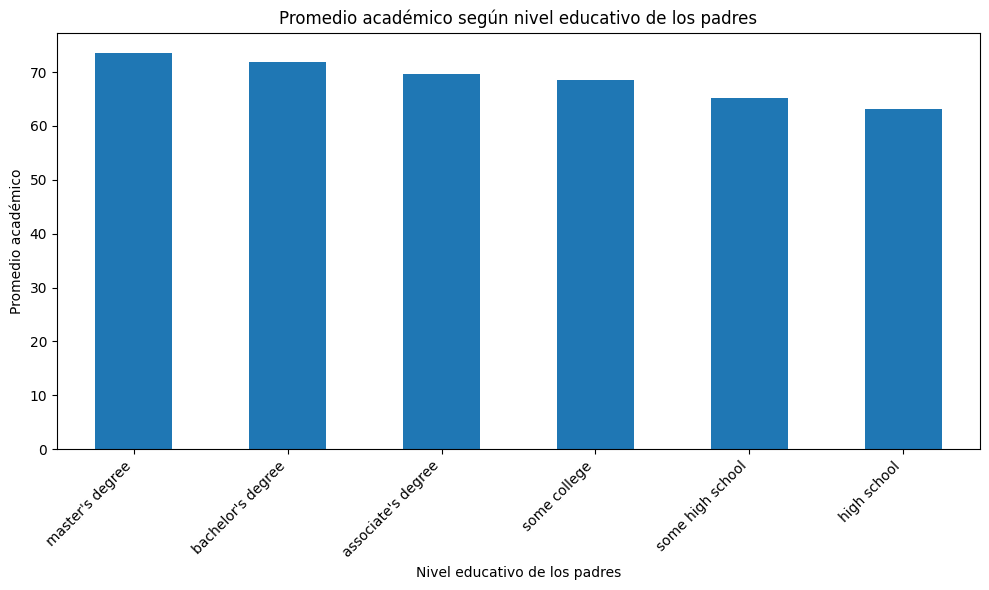

In [53]:
plt.figure(figsize=(10, 6))

promedio_educacion.plot(kind="bar")

plt.title("Promedio académico según nivel educativo de los padres")
plt.xlabel("Nivel educativo de los padres")
plt.ylabel("Promedio académico")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Interpretación

La gráfica muestra cómo cambia el promedio académico de los estudiantes
según el nivel educativo de los padres.

Se pueden comparar las diferentes categorías y observar cuáles presentan
promedios académicos más altos o más bajos dentro de este conjunto de
datos.

Gráfica 3 — Nivel de rendimiento
Pregunta 3

¿Cómo se distribuyen los estudiantes según su nivel de rendimiento académico?

In [54]:
distribucion_rendimiento = df["nivel_rendimiento"].value_counts()

distribucion_rendimiento

,count
nivel_rendimiento,
Bueno,407
Bajo,285
Regular,256
Excelente,52


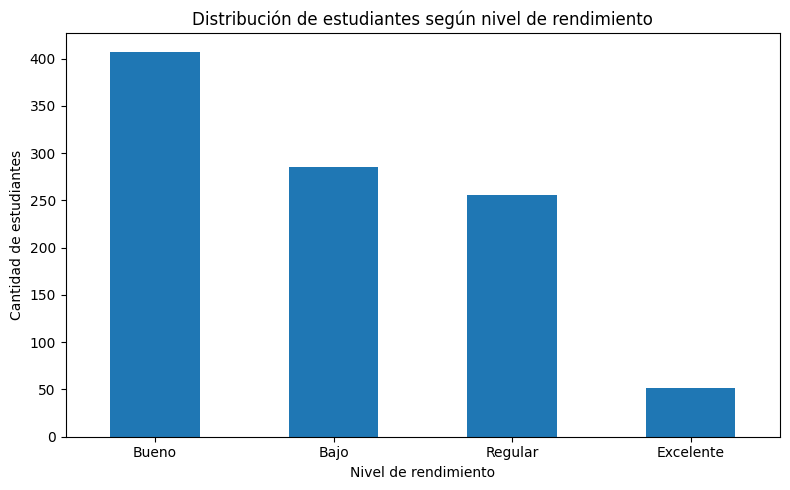

In [55]:
plt.figure(figsize=(8, 5))

distribucion_rendimiento.plot(kind="bar")

plt.title("Distribución de estudiantes según nivel de rendimiento")
plt.xlabel("Nivel de rendimiento")
plt.ylabel("Cantidad de estudiantes")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

 Interpretación

La gráfica muestra la cantidad de estudiantes pertenecientes a cada
nivel de rendimiento académico.

La clasificación se realizó utilizando el promedio obtenido en las
pruebas de matemáticas, lectura y escritura.

Gráfica 4 — Matemáticas vs. lectura

Esta será diferente porque queremos analizar la relación entre dos variables numéricas.

Pregunta 4

¿Existe una relación entre la nota de matemáticas y la nota de lectura?

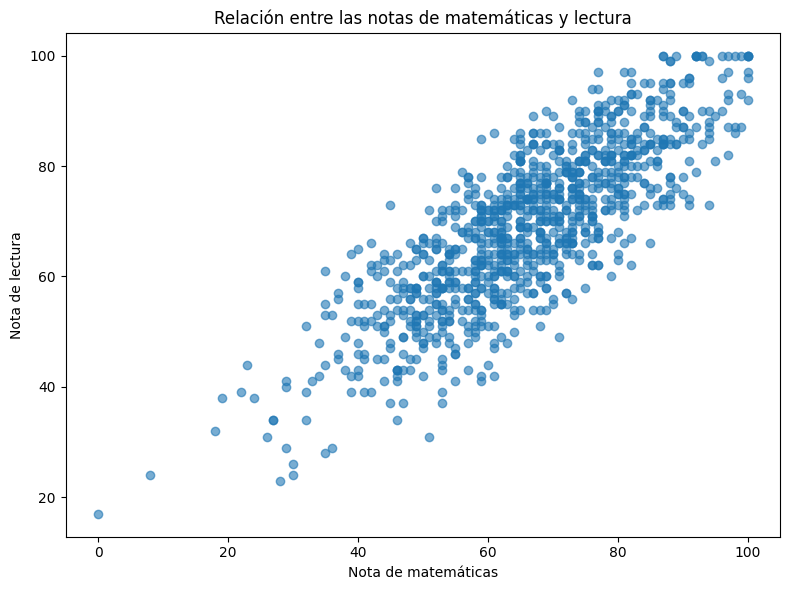

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["nota_matematicas"],
    df["nota_lectura"],
    alpha=0.6
)

plt.title("Relación entre las notas de matemáticas y lectura")
plt.xlabel("Nota de matemáticas")
plt.ylabel("Nota de lectura")

plt.tight_layout()
plt.show()

 Interpretación

El gráfico de dispersión permite observar la relación entre las notas
de matemáticas y lectura.

La distribución de los puntos permite identificar si existe una
tendencia entre ambas variables. Una concentración ascendente de los
puntos indicaría que los estudiantes con mejores resultados en
matemáticas tienden también a presentar mejores resultados en lectura.

Gráfica 5 — Notas según género
Pregunta 5

¿Cómo se comportan las notas de matemáticas, lectura y escritura según el género?

In [57]:
promedios_genero = (
    df.groupby("genero")[
        ["nota_matematicas", "nota_lectura", "nota_escritura"]
    ]
    .mean()
)

promedios_genero

,nota_matematicas,nota_lectura,nota_escritura
genero,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


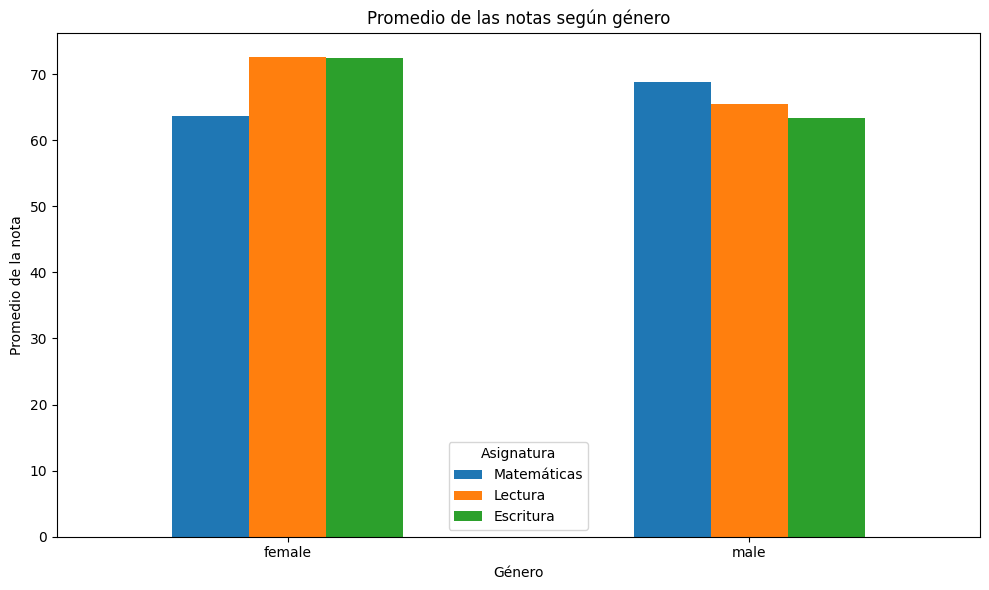

In [58]:
promedios_genero.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Promedio de las notas según género")
plt.xlabel("Género")
plt.ylabel("Promedio de la nota")
plt.xticks(rotation=0)

plt.legend(
    title="Asignatura",
    labels=["Matemáticas", "Lectura", "Escritura"]
)

plt.tight_layout()
plt.show()

Interpretación

La gráfica compara los promedios de matemáticas, lectura y escritura
entre los grupos de género presentes en el conjunto de datos.

Se pueden observar diferencias entre las asignaturas y comparar el
comportamiento de los promedios de cada grupo.

In [59]:
correlacion = df[
    ["nota_matematicas", "nota_lectura", "nota_escritura"]
].corr()

correlacion

,nota_matematicas,nota_lectura,nota_escritura
nota_matematicas,1.000000,0.817580,0.802642
nota_lectura,0.817580,1.000000,0.954598
nota_escritura,0.802642,0.954598,1.000000


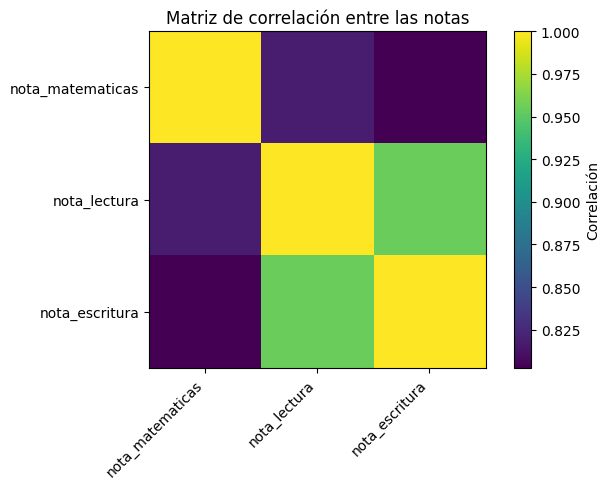

In [60]:
plt.figure(figsize=(7, 5))

plt.imshow(correlacion)

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacion.index)),
    correlacion.index
)

plt.colorbar(label="Correlación")

plt.title("Matriz de correlación entre las notas")

plt.tight_layout()
plt.show()

### Interpretación de la correlación

La matriz de correlación permite analizar la relación lineal entre
las notas de matemáticas, lectura y escritura.

Los valores cercanos a 1 representan una relación positiva fuerte,
mientras que los valores cercanos a 0 representan una relación
lineal débil.

In [61]:
resumen = pd.DataFrame({
    "Promedio por preparación": df.groupby("preparacion_examen")["promedio"].mean(),
    "Promedio por género": df.groupby("genero")["promedio"].mean()
})

resumen.round(2)

,Promedio por preparación,Promedio por género
completed,72.67,NaN
female,NaN,69.57
male,NaN,65.84
none,65.04,NaN


In [62]:
df.groupby("preparacion_examen")["promedio"].agg(
    ["count", "mean", "min", "max"]
).round(2)

,count,mean,min,max
preparacion_examen,,,,
completed,358,72.67,34.33,100.0
none,642,65.04,9.00,100.0


In [63]:
df.groupby("educacion_padres")["promedio"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False).round(2)

,count,mean
educacion_padres,,
master's degree,59,73.60
bachelor's degree,118,71.92
associate's degree,222,69.57
some college,226,68.48
some high school,179,65.11
high school,196,63.10


In [64]:
df["nivel_rendimiento"].value_counts()

,count
nivel_rendimiento,
Bueno,407
Bajo,285
Regular,256
Excelente,52


In [65]:
(
    df["nivel_rendimiento"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

,proportion
nivel_rendimiento,
Bueno,40.7
Bajo,28.5
Regular,25.6
Excelente,5.2


In [66]:
correlacion = df[
    ["nota_matematicas", "nota_lectura", "nota_escritura"]
].corr()

correlacion.round(2)

,nota_matematicas,nota_lectura,nota_escritura
nota_matematicas,1.00,0.82,0.80
nota_lectura,0.82,1.00,0.95
nota_escritura,0.80,0.95,1.00


# Interpretación general de los resultados

El análisis exploratorio permitió identificar diferentes patrones
relacionados con el rendimiento académico de los estudiantes.

En primer lugar, se compararon los promedios según la realización
del curso de preparación para el examen. Esto permitió observar
diferencias entre los grupos.

También se analizó el promedio académico según el nivel educativo
de los padres, encontrando variaciones entre las diferentes
categorías.

La clasificación del rendimiento permitió conocer cómo se distribuyen
los estudiantes entre los diferentes niveles establecidos a partir
del promedio de matemáticas, lectura y escritura.

Por otra parte, el gráfico de dispersión y la matriz de correlación
permitieron analizar la relación existente entre las diferentes
asignaturas.

Finalmente, la comparación por género permitió observar el
comportamiento de los promedios de matemáticas, lectura y escritura
para los grupos presentes en el conjunto de datos.

# Conclusiones

1. El análisis permitió identificar diferencias en el rendimiento
académico según la realización del curso de preparación para el
examen. Los resultados muestran que los grupos presentan diferentes
promedios, lo que permite observar una asociación entre estas
variables dentro del conjunto de datos analizado.

2. El nivel educativo de los padres presenta diferencias en los
promedios académicos de los estudiantes. Esto permite observar que
el rendimiento no se distribuye de la misma manera entre todas las
categorías de educación de los padres.

3. Las notas de matemáticas, lectura y escritura presentan una
relación entre sí. La matriz de correlación permite observar que
los estudiantes que presentan determinados comportamientos en una
asignatura tienden a presentar comportamientos relacionados en las
otras, aunque la correlación no implica causalidad.

4. La creación de la variable `promedio` permitió obtener una medida
general del rendimiento académico de cada estudiante y facilitó la
clasificación en diferentes niveles de rendimiento.

5. El análisis exploratorio permitió utilizar herramientas de Python
y Pandas como `groupby()`, filtrado, creación de variables,
estadísticas descriptivas y visualización para identificar patrones
en el conjunto de datos.